In [2]:
import numpy as np
import pickle
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
PERCEPT_DIR = Path('/media/yiting/NewVolume/Analysis/percept_analysis')
percept_rdm_path = PERCEPT_DIR / 'percept_rdms_for_hand_correct_all.pkl'
with open(percept_rdm_path, 'rb') as f: percept_data = pickle.load(f)

percept_df_path = PERCEPT_DIR / 'percept_log_for_hand_correct_all.csv'
percept_df = pd.read_csv(percept_df_path)

In [4]:
percept_rdm = percept_data['rdm']
shape_ids = percept_data['shape_ids']

Analysis Summary (Excluding Identity Pairs):
-------------------------------------------
Total Unique Off-Diagonal Pairs: 1433
Average Trials per Off-Diagonal Pair: 1.39


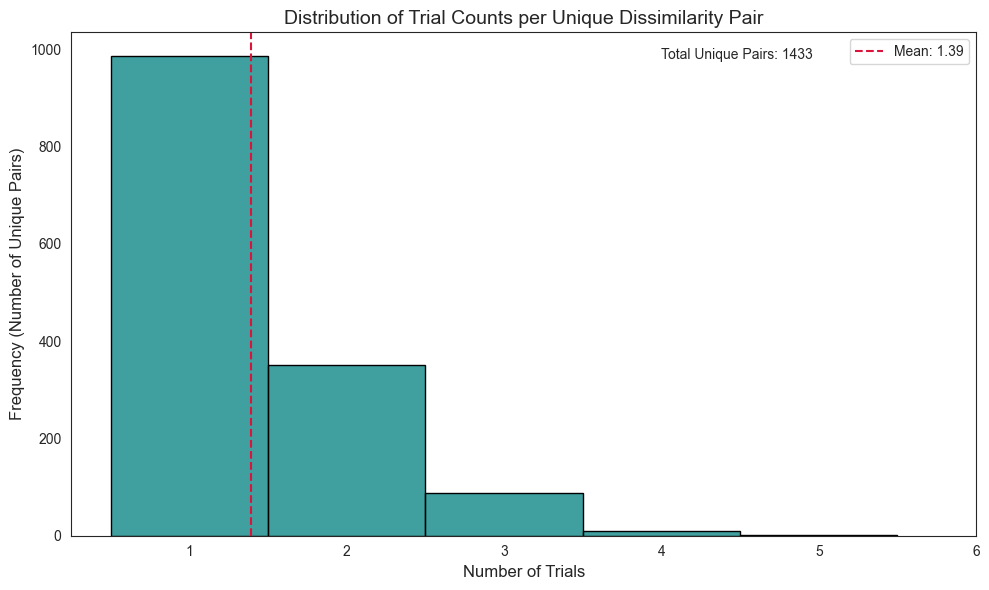

In [15]:
# --- 1. Filter for valid, non-identity pairs ---
# We keep only trials where both current and previous shapes are known,
# and where the current shape is DIFFERENT from the previous shape.
df_pairs = percept_df.dropna(subset=['shape_id', 'prev_shape_id']).copy()
df_diff_pairs = df_pairs[df_pairs['shape_id'] != df_pairs['prev_shape_id']]

# Group to get counts for unique dissimilarity pairs
pair_counts = df_diff_pairs.groupby(['shape_id', 'prev_shape_id']).size().reset_index(name='trial_count')

# --- 2. Calculate Updated Metrics ---
num_unique_pairs = len(pair_counts)
avg_trials_per_pair = pair_counts['trial_count'].mean()

print(f"Analysis Summary (Excluding Identity Pairs):")
print(f"-------------------------------------------")
print(f"Total Unique Off-Diagonal Pairs: {num_unique_pairs}")
print(f"Average Trials per Off-Diagonal Pair: {avg_trials_per_pair:.2f}")

# --- 3. Plot Histogram ---
plt.figure(figsize=(10, 6))
sns.set_style("white")

sns.histplot(pair_counts['trial_count'], bins=range(1, 8), color='teal', edgecolor='black', discrete=True)

plt.title('Distribution of Trial Counts per Unique Dissimilarity Pair', fontsize=14)
plt.xlabel('Number of Trials', fontsize=12)
plt.ylabel('Frequency (Number of Unique Pairs)', fontsize=12)
plt.xticks(range(1, 7))

plt.axvline(avg_trials_per_pair, color='crimson', linestyle='--', label=f'Mean: {avg_trials_per_pair:.2f}')
plt.text(4, 980, f"Total Unique Pairs: {num_unique_pairs}")

plt.legend(loc='upper right')

plt.tight_layout()
plt.savefig(PERCEPT_DIR / "trial_distribution_histogram.png")
plt.show()

In [6]:
# Optional: View the 'rarest' and 'most common' pairs
print("\nTop 5 Most Frequent Pairs:")
print(pair_counts.sort_values('trial_count', ascending=False).head())


Top 5 Most Frequent Pairs:
     shape_id prev_shape_id  trial_count
591    G143_2        G143_2           10
317    G095_0        G095_0           10
370    G112_0        G112_0            9
215    G034_0        G034_0            9
1617  G801_02       G801_02            8
